<a href="https://colab.research.google.com/github/jggoncalez/cardiovascular-diseases-AI/blob/main/notebooks/analise_exploratoria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Exploratória
Este notebook realiza a **Análise Exploratória dos Dados** (EDA)
do dataset de doenças cardiovasculares, disponível no
[Mendeley Data](https://data.mendeley.com/datasets/dzz48mvjht/1).

O objetivo é entender a distribuição dos dados, identificar
padrões relevantes e visualizar a relação entre as variáveis
clínicas dos pacientes e o diagnóstico de doença cardíaca.

### O que você vai encontrar aqui:
- Carregamento e visualização inicial dos dados
- 5 gráficos exploratórios com interpretação

### Setup Inicial

In [ ]:
url = "https://raw.githubusercontent.com/jggoncalez/cardiovascular-diseases-AI/main/data/Cardiovascular_Disease_Dataset.csv"

In [ ]:
%pip install -r "https://raw.githubusercontent.com/jggoncalez/cardiovascular-diseases-AI/refs/heads/main/requirements.txt"

Cloning into 'cardiovascular-diseases-AI'...
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 11 (delta 1), reused 8 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (11/11), 17.25 KiB | 5.75 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/cardiovascular-diseases-AI
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 5.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv(url)

In [ ]:
data.head()

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
0,103368,53,Masculino,2,171,0,0,1,147,0,5.3,3,3,NaN
1,119250,40,Masculino,0,94,229,0,1,115,0,3.7,1,1,NaN
2,119372,49,Masculino,2,133,142,0,0,202,1,5.0,1,0,NaN
3,132514,43,Masculino,0,138,295,1,1,153,0,3.2,2,2,NaN
4,146211,31,Masculino,1,199,0,0,2,136,0,5.3,3,2,NaN


### Análise Exploratória de Dados

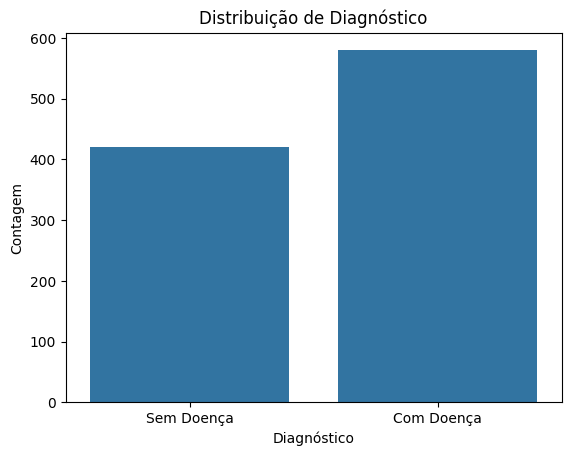

In [ ]:
# Distribuição de target

data_plot = data.copy()
data_plot['target'] = data_plot['target'].map({0: 'Sem Doença', 1: 'Com Doença'})

sns.countplot(x='target', data=data_plot, order=['Sem Doença', 'Com Doença'])
plt.title('Distribuição de Diagnóstico')
plt.xlabel('Diagnóstico')
plt.ylabel('Contagem')
plt.show()

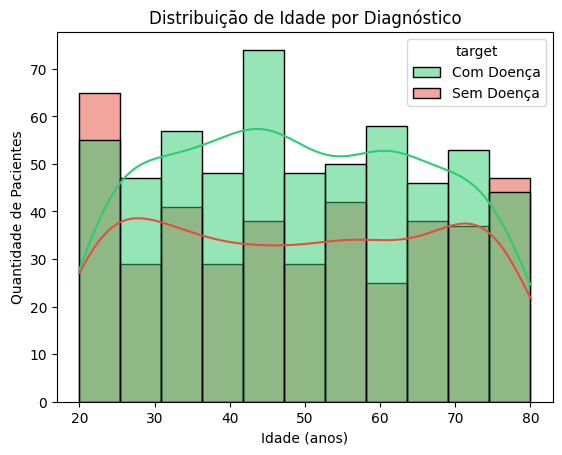

In [ ]:
# Idade por diagnóstico

data_plot = data.copy()
data_plot['target'] = data_plot['target'].map({0: 'Sem Doença', 1: 'Com Doença'})

sns.histplot(data=data_plot, x='age', hue='target', kde=True, palette=['#2ecc71', '#e74c3c'])
plt.title('Distribuição de Idade por Diagnóstico')
plt.xlabel('Idade (anos)')
plt.ylabel('Quantidade de Pacientes')
plt.show()

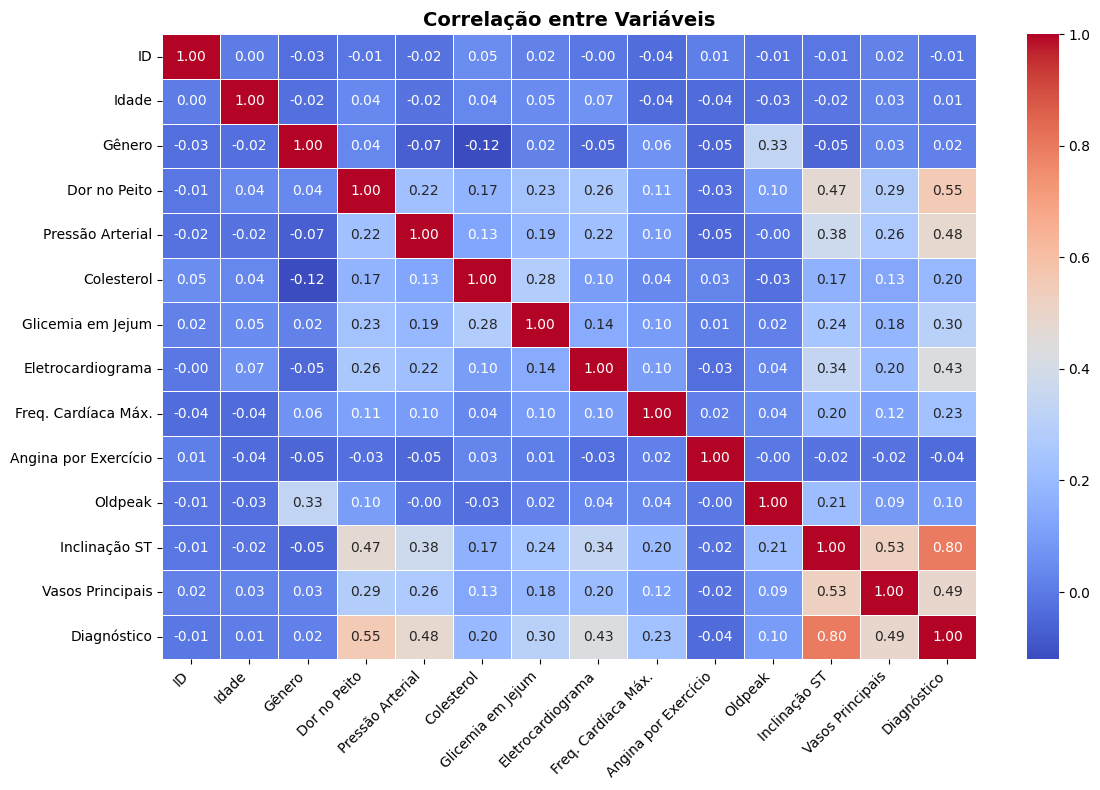

In [ ]:
# Heatmap por correlação

colunas_pt = {
    'patientid': "ID",
    'age': 'Idade',
    'gender': 'Gênero',
    'chestpain': 'Dor no Peito',
    'restingBP': 'Pressão Arterial',
    'serumcholestrol': 'Colesterol',
    'fastingbloodsugar': 'Glicemia em Jejum',
    'restingrelectro': 'Eletrocardiograma',
    'maxheartrate': 'Freq. Cardíaca Máx.',
    'exerciseangia': 'Angina por Exercício',
    'oldpeak': 'Oldpeak',
    'slope': 'Inclinação ST',
    'noofmajorvessels': 'Vasos Principais',
    'target': 'Diagnóstico'
}

data_plot = data.rename(columns=colunas_pt)

plt.figure(figsize=(12, 8))
sns.heatmap(data_plot.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlação entre Variáveis', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

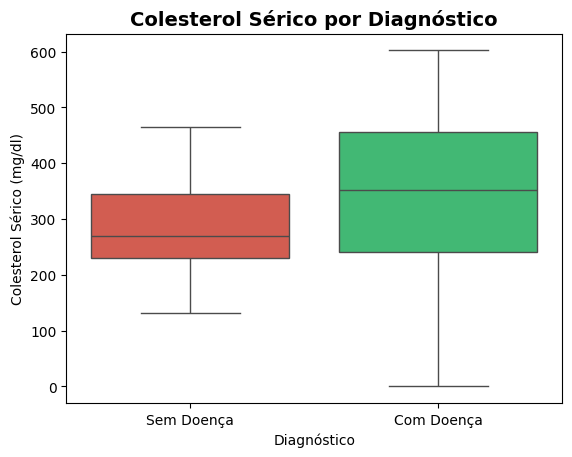

In [ ]:
# Colesterol por diagnóstico

data_plot = data.copy()
data_plot['target'] = data_plot['target'].map({0: 'Sem Doença', 1: 'Com Doença'})

sns.boxplot(x='target', y='serumcholestrol', data=data_plot, order=['Sem Doença', 'Com Doença'], hue='target', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Colesterol Sérico por Diagnóstico', fontsize=14, fontweight='bold')
plt.xlabel('Diagnóstico')
plt.ylabel('Colesterol Sérico (mg/dl)')
plt.show()

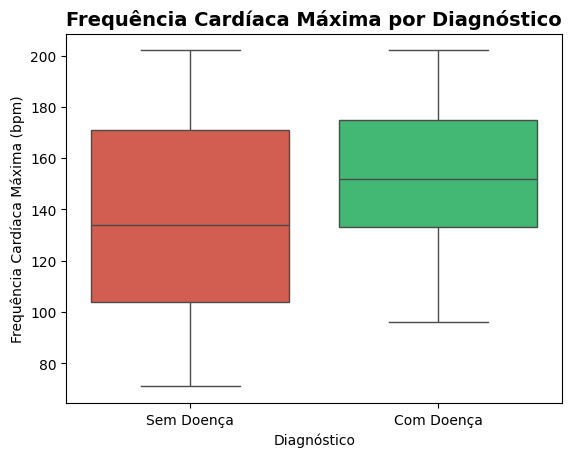

In [ ]:
# Frequência Cardíaca Máxima

data_plot = data.copy()
data_plot['target'] = data_plot['target'].map({0: 'Sem Doença', 1: 'Com Doença'})

sns.boxplot(x='target', y='maxheartrate', data=data_plot, order=['Sem Doença', 'Com Doença'], hue='target', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Frequência Cardíaca Máxima por Diagnóstico', fontsize=14, fontweight='bold')
plt.xlabel('Diagnóstico')
plt.ylabel('Frequência Cardíaca Máxima (bpm)')
plt.show()